# Liminosity Schechter

In [1]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Luminosity sampling

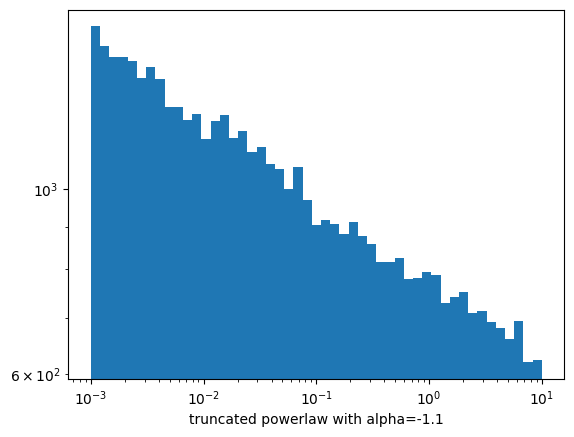

In [3]:
def sample_truncated_power_law(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ x^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin ** exponent
    xmax_exp = xmax ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return samples


x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 14702


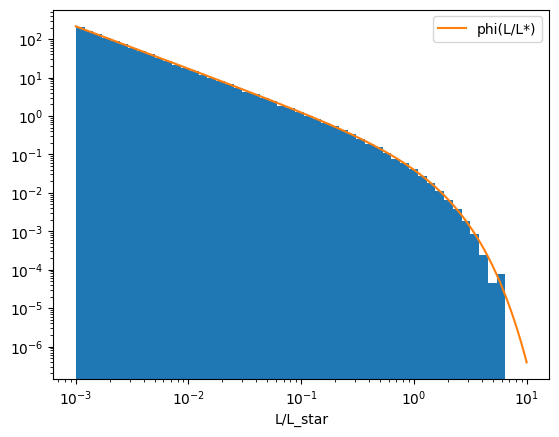

In [4]:
def proba_schechter_lumRatio(x, alpha, phi_star=1):
        return phi_star * np.power(x, alpha) * np.exp(-x)


def generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star=1, get_proba=False):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    reject = 0
    
    while len(samples) < N:
        L_cand = sample_truncated_power_law(alpha, x_min, x_max)
        
        # Acceptance ratio:
        # f(x) = x^alpha * exp(-x)
        # g(x) = x^alpha (on ignore la constante de normalisation qui s'annule)
        # f(x)/g(x) = exp(-x)
        acceptance_ratio = np.exp(-L_cand)
        
        # Acceptance test:
        u = np.random.uniform(0, 1)
        if u < acceptance_ratio:
            samples.append(L_cand)
        else:
            reject += 1
    print('Number of rejects =', reject)
    if get_proba: return np.array(samples), np.array(proba)
    else: return np.array(samples)


L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True, density=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test / np.trapz(phi_test, L_test), label = 'phi(L/L*)') #np.trapz ti normalize phi.
plt.legend();

### z, m, M, L, dL_mpc:

Number of rejects = 14487


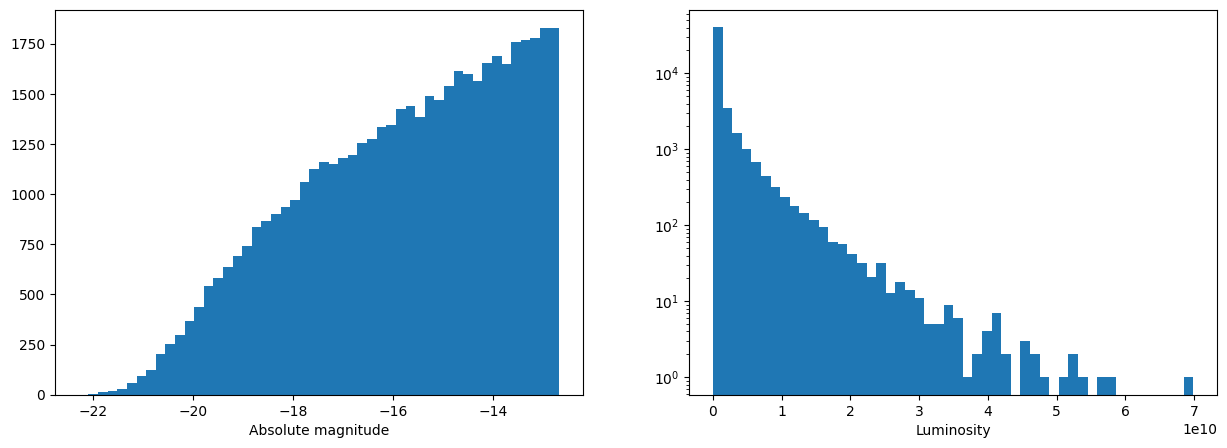

In [7]:
def generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star):
    x_min, x_max = L_min/L_star, L_max/L_star
    return L_star*generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star)


def lum2absMag(L, M_sun=4.83, L_sun=1):
    return M_sun - 2.5*np.log10(L/L_sun)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def generate_lumMag(N, L_min=1e7, L_max=1e11,  L_star=1e10, alpha=-1.1, z_min=0.01, z_max=3.0, phi_star=1, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    L_sun = kwargs.get('L_sun', 1) #Luminosity of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    L = generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star)  #luminosities
    M = lum2absMag(L, M_sun, L_sun) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes
    return z, m, M, L, dL_mpc



z, m, M, L, dL_mpc = generate_lumMag(npix)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=50, figax=(fig, ax[1]), log=True);

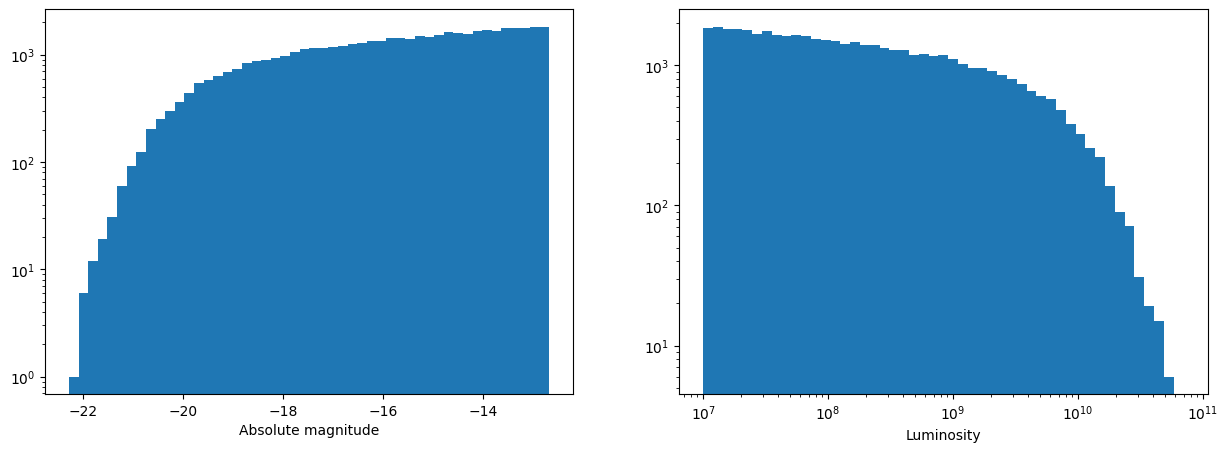

In [8]:
binsL = np.logspace(np.log10(np.min(L)), np.log10(np.max(L)), 50)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(M, xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(L, xlabel='Luminosity', bins=binsL, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log');

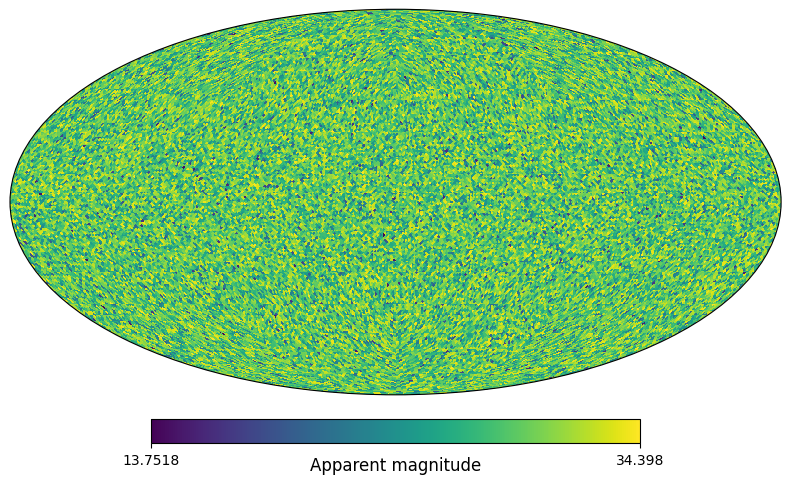

In [11]:
hp.projview(m, unit="Apparent magnitude");